In [1]:
import pandas as pd
df = pd.read_csv(r'C:\dev\data-science\All_libs\Pandas\assets\student_habits_performance.csv')

In [2]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.drop_duplicates(['sleep_hours', 'study_hours_per_day'], inplace=True)

In [4]:
ages_prob = df['age'].value_counts(normalize=True, sort=True, ascending=False) # Distribuição de probabilidade

In [5]:
ages_prob

age
20    0.155637
21    0.129902
17    0.129902
24    0.127451
23    0.122549
19    0.111520
18    0.111520
22    0.111520
Name: proportion, dtype: float64

<BarContainer object of 8 artists>

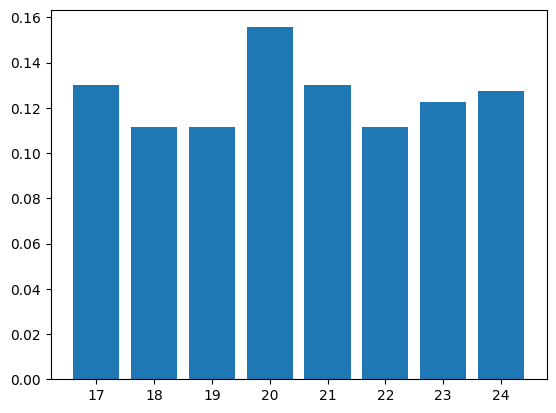

In [6]:
import matplotlib.pyplot as plt

plt.bar(ages_prob.index, ages_prob.values)

In [7]:
df.groupby(['age', 'gender'])['study_hours_per_day'].mean()

age  gender
17   Female    3.538298
     Male      3.594545
     Other     2.850000
18   Female    3.932000
     Male      3.331579
     Other     3.766667
19   Female    3.541304
     Male      3.450000
     Other     2.500000
20   Female    3.625000
     Male      3.408333
     Other     3.742857
21   Female    3.611538
     Male      3.360417
     Other     4.066667
22   Female    3.703922
     Male      3.656410
     Other     3.000000
23   Female    3.470455
     Male      3.617647
     Other     4.380000
24   Female    3.471429
     Male      3.508929
     Other     3.833333
Name: study_hours_per_day, dtype: float64

In [8]:
df.pivot_table('study_hours_per_day', index='gender', columns='age', margins=True)

age,17,18,19,20,21,22,23,24,All
gender,,,,,,,,,
Female,3.538298,3.932000,3.541304,3.625000,3.611538,3.703922,3.470455,3.471429,3.618622
Male,3.594545,3.331579,3.450000,3.408333,3.360417,3.656410,3.617647,3.508929,3.492545
Other,2.850000,3.766667,2.500000,3.742857,4.066667,3.000000,4.380000,3.833333,3.677143
All,3.541509,3.675824,3.464835,3.529134,3.523585,3.675824,3.591000,3.512500,3.561029


In [9]:
df = df.set_index('parental_education_level')

In [10]:
df.loc[['Master', 'High School'], 'social_media_hours'].sort_index()

parental_education_level
High School    4.5
High School    1.3
High School    2.9
High School    2.9
High School    4.2
              ... 
Master         2.0
Master         1.7
Master         2.3
Master         1.5
Master         1.2
Name: social_media_hours, Length: 455, dtype: float64

In [11]:
#df = df.reset_index()

In [12]:
#df = df.set_index(['diet_quality', 'parental_education_level']).sort_index(level=[0, 1])

In [13]:
df[df['exam_score'].between(70, 100)]

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,internet_quality,mental_health_rating,extracurricular_participation,exam_score
parental_education_level,,,,,,,,,,,,,,,
High School,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,Average,8,No,100.0
Master,S1005,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Average,4,No,100.0
Master,S1006,21,Female,5.6,1.5,1.4,Yes,85.8,6.5,Good,2,Poor,4,No,89.8
Bachelor,S1007,21,Female,4.3,1.0,2.0,Yes,77.7,4.6,Fair,0,Average,8,No,72.6
Bachelor,S1008,23,Female,4.4,2.2,1.7,No,100.0,7.1,Good,3,Good,1,No,78.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Bachelor,S1988,18,Male,3.3,2.4,1.2,No,67.5,4.1,Fair,4,Average,8,Yes,72.5
High School,S1991,20,Male,6.0,2.1,3.0,No,86.7,5.1,Good,2,Good,3,No,85.3
Bachelor,S1992,18,Male,3.5,0.0,1.9,No,96.8,6.4,Fair,3,Poor,3,No,71.8


In [14]:
df.index.unique()

Index(['Master', 'High School', 'Bachelor', nan], dtype='object', name='parental_education_level')

In [15]:
df.mean(axis='index', numeric_only=True)

age                      20.506127
study_hours_per_day       3.561029
social_media_hours        2.511887
netflix_hours             1.829412
attendance_percentage    84.126593
sleep_hours               6.468627
exercise_frequency        3.078431
mental_health_rating      5.399510
exam_score               69.666544
dtype: float64

In [16]:
df.groupby(level=0).mean(numeric_only=True)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
parental_education_level,,,,,,,,,
Bachelor,20.565068,3.511644,2.468836,1.856164,84.198973,6.525342,3.160959,5.746575,70.502055
High School,20.334385,3.559306,2.554574,1.847634,84.053628,6.441009,3.113565,5.356467,69.405994
Master,20.536232,3.639130,2.520290,1.805797,82.818116,6.424638,2.826087,4.811594,68.284058
